# LSTM Time Series Forecasting- Model

## 1. Importing the libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

## 2. loading the data

In [23]:
#taking the input to ask the user to choose the company
name = input("Enter the name of the company").upper()
name

#taking the dataset 
df = pd.read_csv(f"../data-companywise/processed_data/{name}.csv")
df

Enter the name of the company shl


,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0,3932807.0,2022,1.95,98.4,11.5,26.3
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0,3749380.5,2022,1.95,98.4,11.5,26.3
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0,7770474.5,2022,1.95,98.4,11.5,26.3
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0,3707132.8,2022,1.95,98.4,11.5,26.3
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0,6320346.1,2022,1.95,98.4,11.5,26.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0,7425662.4,2025,6.56,81.7,25.6,31.6
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0,5374158.5,2025,6.56,81.7,25.6,31.6
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0,5920904.6,2025,6.56,81.7,25.6,31.6
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0,14280950.5,2025,6.56,81.7,25.6,31.6


## 3. Dropping the unnecessary columns

In [24]:
#eps, pe, roe and dividend, turnover, year
df.drop(columns = ['eps','roe','dividend','pe-ratio', 'year','turnover'],inplace = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0


In [25]:
# reviewing the data
print(df.head())
print(df.shape)
print(df.dtypes)


         date   open   high    low  close  price_change_pct   volume
0  2022-01-02  210.5  210.5  205.8  208.0             -0.48  18999.0
1  2022-01-03  209.0  213.0  208.0  211.0              1.44  17758.0
2  2022-01-04  210.0  215.3  208.0  214.0              1.42  36481.0
3  2022-01-05  214.0  217.0  208.8  210.3             -1.73  17351.0
4  2022-01-06  211.0  220.0  208.0  217.0              3.19  29617.0
(928, 7)
date                 object
open                float64
high                float64
low                 float64
close               float64
price_change_pct    float64
volume              float64
dtype: object


## 4. Cleaning and preparing the data

In [26]:
#Converting the date to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df =  df.sort_values('date').reset_index(drop = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
1,2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2,2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
3,2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
4,2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...,...
923,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
924,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
925,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0
926,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177.0


In [27]:
#chceking for the null values
df.isnull().sum()

date                0
open                0
high                0
low                 0
close               0
price_change_pct    0
volume              0
dtype: int64

In [28]:
#total traded days
print(f"total trading days :{len(df)}")

total trading days :928


In [29]:
# 3. Set as index
df.set_index('date', inplace=True)

In [30]:
df

,open,high,low,close,price_change_pct,volume
date,,,,,,
2022-01-02,210.5,210.5,205.8,208.0,-0.48,18999.0
2022-01-03,209.0,213.0,208.0,211.0,1.44,17758.0
2022-01-04,210.0,215.3,208.0,214.0,1.42,36481.0
2022-01-05,214.0,217.0,208.8,210.3,-1.73,17351.0
2022-01-06,211.0,220.0,208.0,217.0,3.19,29617.0
...,...,...,...,...,...,...
2025-12-23,478.0,485.0,471.0,479.5,0.19,15466.0
2025-12-24,479.5,486.0,475.0,480.5,0.21,11182.0
2025-12-28,470.9,490.1,470.9,488.5,1.66,12144.0


## 5. Visualizing the all features

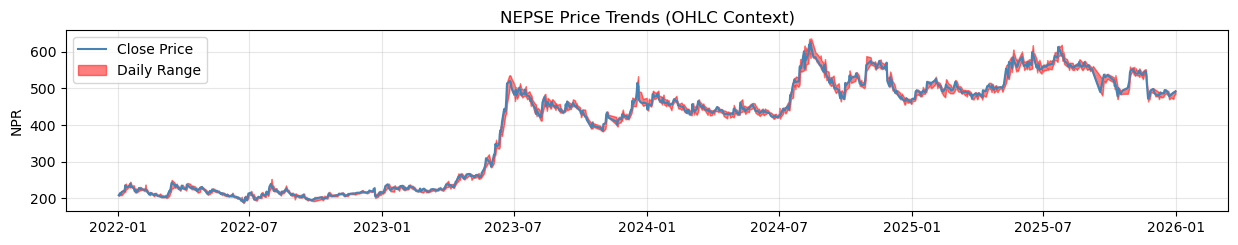

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#plotting the price trends
plt.figure(figsize = (15,8))
plt.subplot(3,1,1)
plt.plot(df.index, df['close'], label='Close Price', color='steelblue', linewidth=1.5)
plt.fill_between(df.index, df['low'], df['high'], alpha=0.5, color='red', label='Daily Range')
plt.title('NEPSE Price Trends (OHLC Context)')
plt.ylabel('NPR')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

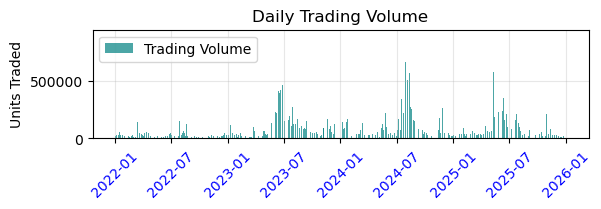

In [50]:
# 2. Plotting Volume (Market Activity)
plt.subplot(3, 1, 2)
plt.bar(df.index, df['volume'], color='teal', alpha=0.7, label='Trading Volume')
plt.title('Daily Trading Volume')
plt.ylabel('Units Traded')
plt.legend(loc='upper left')
plt.xticks(rotation=45, color = 'blue')
plt.grid(True, alpha=0.3)
plt.show()

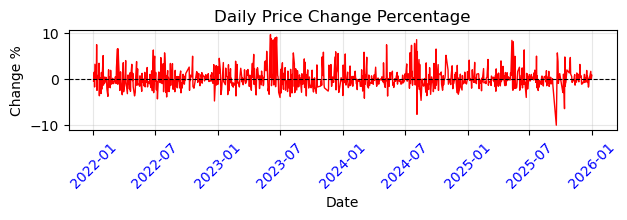

In [58]:
# 3. Plotting Price Change % (Momentum)
plt.subplot(3, 1, 3)
plt.plot(df.index, df['price_change_pct'], color='red', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Zero line
plt.title('Daily Price Change Percentage')
plt.xlabel('Date')
plt.ylabel('Change %')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, color = 'blue')
plt.tight_layout()
plt.show()

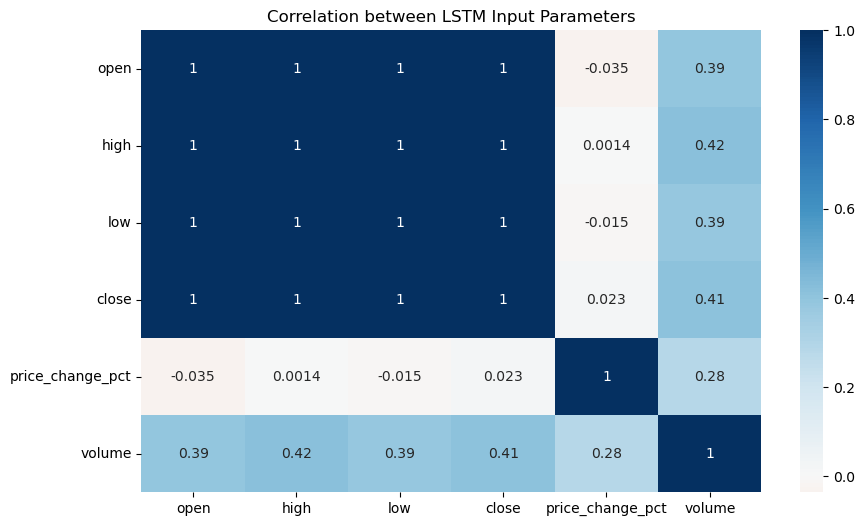

In [71]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', center=0) #rdbu re
plt.title('Correlation between LSTM Input Parameters')
plt.show()

## 6- Scaling the data

In [73]:
#using the minmax scaler concpet 
from sklearn.preprocessing import MinMaxScaler

#selecting the features
features = ['open','high','low','close','volume','price_change_pct']
data_to_scale =  df[features].values

#Scale all features between 0 and 1 
scaler =  MinMaxScaler(feature_range= (0,1))
scaled_data = scaler.fit_transform(data_to_scale)

scaled_data



array([[0.04804469, 0.03728814, 0.04544373, 0.04344828, 0.01822266,
        0.48521916],
       [0.04469274, 0.04293785, 0.05067809, 0.05034483, 0.0168407 ,
        0.58307849],
       [0.04692737, 0.04813559, 0.05067809, 0.05724138, 0.0376903 ,
        0.58205912],
       ...,
       [0.62994413, 0.66915254, 0.67618368, 0.68827586, 0.01058905,
        0.59429154],
       [0.66145251, 0.67570621, 0.69783488, 0.68735632, 0.02955669,
        0.50560652],
       [0.67932961, 0.67570621, 0.70973114, 0.69632184, 0.02599769,
        0.55045872]])

## 7. Creating the multivariate sequences

In [74]:
#because only single value closing price doesnot tell the whole story
#creating the sequences using the scaled data
WINDOW_SIZE = 60

def create_multivariate_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        # We take the window of all 6 scaled features for X
        X.append(data[i-window_size:i, :]) 
        
        # We take only the 'Close' price (index 3) for the target y
        y.append(data[i, 3]) 
    return np.array(X), np.array(y)

# Use scaled_data here!
X, y = create_multivariate_sequences(scaled_data, WINDOW_SIZE)

In [79]:
print(f"Total samples: {len(X)}")
print(f"Shape of one input window (X[0]): {X[0].shape}") # Should be (60, 6)
print(f"Last trading day target value (y[0]): {y[-1]}")  # close price of last trading date    
# Should be a value between 0 and 1

Total samples: 868
Shape of one input window (X[0]): (60, 6)
First target value (y[0]): 0.6963218390804597


## 7. Splitting of data into the training and test dataset

In [86]:
#80% is for the training and remaining 20% is for the testing 
split_index  = int(len(X) *0.80)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training samples: {len(X_train)}") # ~646 sequences
print(f"Testing samples:  {len(X_test)}")  # ~162 sequences

Training samples: 694
Testing samples:  174


## 8. Defining the LSTM model architecture

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    #layer -1: layer- basic patterns
    LSTM(units = 50, return_sequences =True, input_shape = (X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    #layer - 2: 
    LSTM(units = 50, return_sequences =False),
    Dropout(0.2),

    #layer - 3: Dense - help between the correlation betn the target
    Dense(units = 100, activation = 'relu'),

    #layer - 4: Dropout layer- to prevent the overfitting
    Dropout(0.5),

    #layer -5: output layer
    Dense(units=1)
])

model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │           5,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,801 (143.75 KB)

 Trainable params: 36,801 (143.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Training the Model

In [95]:
history = model.fit(
    X_train, y_train,
    epochs=50,            # how many times to go through all training data
    batch_size=32,        # process 32 samples at a time
    validation_split=0.1, # use 10% of training data to monitor overfitting
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0610 - val_loss: 0.0198
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0187 - val_loss: 0.0073
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0143 - val_loss: 0.0082
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0140 - val_loss: 0.0030
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0119 - val_loss: 0.0021
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0107 - val_loss: 0.0030
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0106 - val_loss: 0.0080
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0093 - val_loss: 0.0109
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0093 - val_loss: 0.0035
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0100 - val_loss: 0.0032
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0083 - val_loss: 0.0024
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0

## 10. Visualizing the training loss

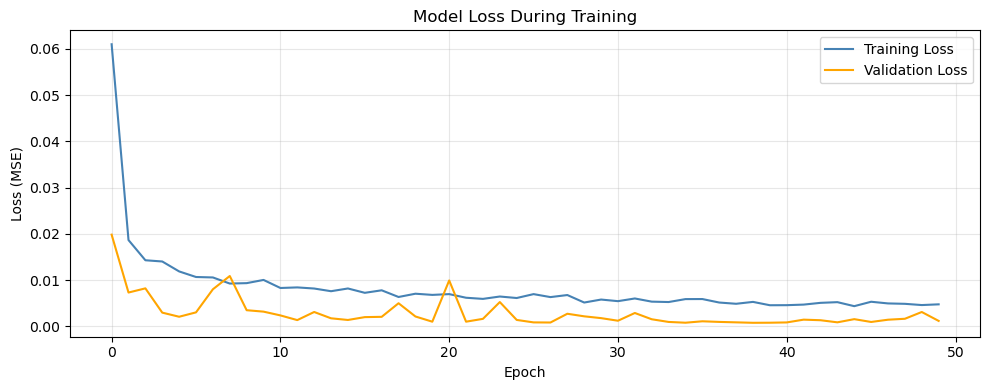

In [96]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='steelblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Good sign: both lines going DOWN and staying close together
# Bad sign:  val_loss going UP while train_loss goes down = overfitting

## 11. Make predictions and inverse Scaling

In [99]:
import numpy as np
#make predictions
predictions_scaled = model.predict(X_test)

dummy = np.zeros((len(predictions_scaled),6))
dummy

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [100]:
#putting the predictions into the 4th column
dummy[:,3] = predictions_scaled.flatten()
dummy

array([[0.        , 0.        , 0.        , 0.70530808, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.70216352, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.70004147, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , 0.69228071, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.69266075, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.69408375, 0.        ,
        0.        ]])

In [101]:
#reverse transformation
final_predictions = scaler.inverse_transform(dummy)[:,3]
final_predictions

array([495.90901468, 494.5411301 , 493.61804072, 491.46622244,
       490.46182278, 489.55068622, 489.78842024, 488.79636232,
       488.75186983, 489.34030626, 488.74051336, 487.712234  ,
       490.2021018 , 491.65059659, 492.66165975, 497.13616196,
       501.14198927, 505.63860807, 508.14058427, 509.3183646 ,
       511.79542396, 512.49586943, 511.12406973, 511.60542343,
       511.11483935, 509.3699095 , 508.2076082 , 507.75671992,
       506.62081335, 505.76772962, 506.61433134, 509.1172928 ,
       527.5009853 , 539.70981601, 546.00368742, 567.11111847,
       579.18315295, 583.4897453 , 591.2657142 , 596.07297662,
       595.863919  , 591.24865357, 583.97309545, 576.45378802,
       572.84810785, 578.41236476, 576.98741261, 571.51102576,
       566.21242735, 564.3874577 , 561.70629296, 563.12745962,
       561.51655171, 564.00323037, 562.63306413, 579.74182401,
       590.89725111, 591.0433555 , 590.4559562 , 583.49441234,
       575.26742551, 566.18074331, 558.77780083, 554.10

## 12. Final Visualization- Result (Actual vs Predicted Prices)

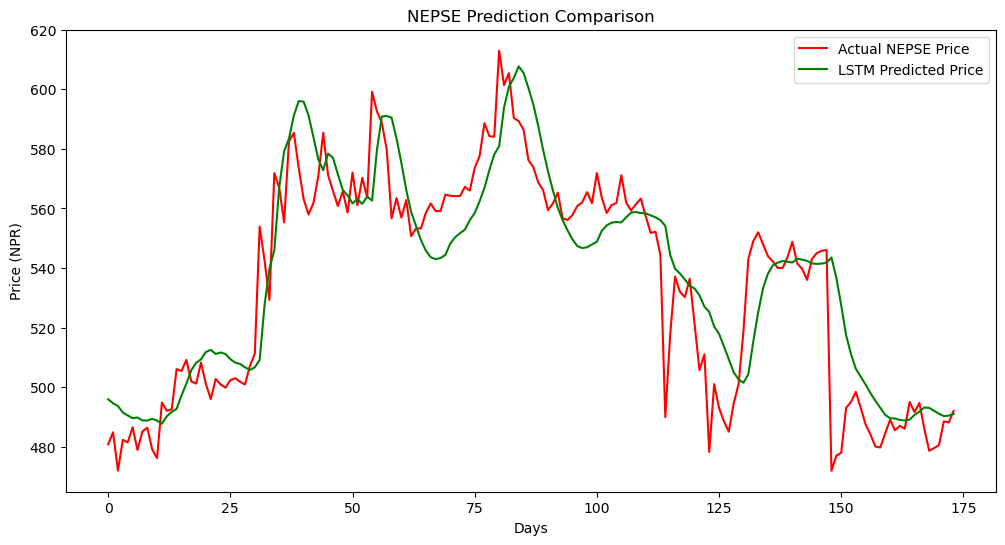

In [105]:
import matplotlib.pyplot as plt

# Get the actual closing prices for the test period
actual_dummy = np.zeros((len(y_test), 6))
actual_dummy[:, 3] = y_test
final_actual_npr = scaler.inverse_transform(actual_dummy)[:, 3]

# Plotting
plt.figure(figsize=(12,6))
plt.plot(final_actual_npr, color='red', label='Actual NEPSE Price')
plt.plot(final_predictions, color='green', label='LSTM Predicted Price')
plt.title('NEPSE Prediction Comparison')
plt.xlabel('Days')
plt.ylabel('Price (NPR)')
plt.legend()
plt.show()

## 13. Performance Matrix

In [106]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(final_actual_npr, final_predictions))
mape = np.mean(np.abs((final_actual_npr - final_predictions) / final_actual_npr)) * 100

print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} NPR")

Mean Absolute Percentage Error (MAPE): 2.35%
Root Mean Squared Error (RMSE): 17.20 NPR


## 14. Predicting the Tomorrow Price

In [107]:
# 1. Take the last 60 days from your scaled data
last_60_days = scaled_data[-60:].reshape(1, 60, 6)

# 2. Predict
tomorrow_scaled = model.predict(last_60_days)

# 3. Inverse scale
tomorrow_dummy = np.zeros((1, 6))
tomorrow_dummy[0, 3] = tomorrow_scaled
tomorrow_price = scaler.inverse_transform(tomorrow_dummy)[0, 3]

print(f"The predicted NEPSE Close for the next trading day is: NPR {tomorrow_price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
The predicted NEPSE Close for the next trading day is: NPR 492.32


In [109]:
last_actual_price = df['close'].iloc[-1]
change = tomorrow_price - last_actual_price
direction = "UP 📈" if change > 0 else "DOWN 📉"

print(f"Change: {change:.2f} NPR ({direction})")

Change: 0.32 NPR (UP 📈)


In [1]:
# taken this as references
https://www.youtube.com/watch?v=94PlBzgeq90&t=1s